In [5]:
import cmdstanpy as csp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
csp.install_cmdstan(dir="C:/cmdstan", overwrite=True, compiler=True)

15:52:28 - cmdstanpy - INFO - Add C++ toolchain to $PATH: C:\cmdstan\RTools40


CmdStan install directory: C:/cmdstan
Installing CmdStan version: 2.37.0
Download successful, file: C:\Users\sebas\AppData\Local\Temp\tmp7e_mxv_3
Extracting distribution
Unpacked download as cmdstan-2.37.0
Building version cmdstan-2.37.0, may take several minutes, depending on your system.
Installed cmdstan-2.37.0
Test model compilation


True

In [ ]:
csp.set_cmdstan_path("C:\\cmdstan\\cmdstan-2.37.0")

In [6]:
df = pd.read_csv("../no2.csv")
df["day"] = df.index + 1

In [7]:
# Example for Weekly (J=3) and Yearly (J=10) seasonality
data_dict = {
    "n": len(df),
    "t": df['day'].values,
    "y": df['no2'].values,
    "num_seasonal": 2,
    "J": [2, 5],
    "periods": [7, 365.25]
}

In [ ]:
model = csp.CmdStanModel(stan_file="harmonic_2.stan", force_compile=True, cpp_options={"STAN_THREADS": "TRUE"})
# model = csp.CmdStanModel(exe_file="harmonic_2.exe")

15:58:19 - cmdstanpy - INFO - compiling stan file C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\harmonic_2.stan to exe file C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\harmonic_2.exe
16:01:00 - cmdstanpy - INFO - compiled model executable: C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\harmonic_2.exe


In [ ]:
fit = model.sample(
    data=data_dict,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_console=True,
    threads_per_chain=4
)

16:01:00 - cmdstanpy - INFO - CmdStan start processing


method = sample (Default)
sample
num_samples = 1000 (Default)
num_warmup = 1000 (Default)
save_warmup = false (Default)
thin = 1 (Default)
adapt
engaged = true (Default)
gamma = 0.05 (Default)
delta = 0.8 (Default)
kappa = 0.75 (Default)
t0 = 10 (Default)
init_buffer = 75 (Default)
term_buffer = 50 (Default)
window = 25 (Default)
save_metric = false (Default)
algorithm = hmc (Default)
hmc
engine = nuts (Default)
nuts
max_depth = 10 (Default)
metric = diag_e (Default)
metric_file =  (Default)
stepsize = 1 (Default)
stepsize_jitter = 0 (Default)
num_chains = 4
id = 1 (Default)
data
file = C:\Users\sebas\AppData\Local\Temp\tmpd6rn9b5a\bmf1_5j2.json
init = 2 (Default)
random
seed = 42
output
file = C:\Users\sebas\AppData\Local\Temp\tmpd6rn9b5a\harmonic_2tv3e0600\harmonic_2-20260104160100.csv
diagnostic_file =  (Default)
refresh = 100 (Default)
sig_figs = 8 (Default)
profile_file = profile.csv (Default)
save_cmdstan_config = false (Default)
num_threads = 16 (Default)


Gradient evaluation t

19:23:37 - cmdstanpy - INFO - CmdStan done processing



Elapsed Time: 7400.93 seconds (Warm-up)
4754.64 seconds (Sampling)
12155.6 seconds (Total)











































































































































In [ ]:
fit.save_csvfiles("mulseasonal.csv")

In [ ]:
# 1. Get the summary DataFrame
summary_df = fit.summary()

# 2. Save to CSV
summary_df.to_csv("model_parameters_summary_multiseason.csv")

# 3. Or save to Excel (requires 'openpyxl' library)
# summary_df.to_excel("model_parameters.xlsx")

In [ ]:
import pickle
with open('no2_model_fit.pkl', 'wb') as f:
    pickle.dump(fit, f)

In [ ]:
import arviz as az

idata = az.from_cmdstanpy(fit)
idata.to_netcdf("no2_results_mseason.nc")

'no2_results_mseason.nc'

                mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha        114.720  0.601  113.582  115.820      0.009    0.012    4328.0   
beta          -0.006  0.000   -0.006   -0.006      0.000    0.000    3742.0   
sigma         30.232  0.193   29.861   30.586      0.003    0.004    5899.0   
beta_cos[0]    8.102  0.387    7.405    8.843      0.005    0.007    5060.0   
beta_cos[1]   -3.696  0.376   -4.425   -3.005      0.005    0.007    6365.0   
beta_cos[2]   -1.934  0.384   -2.676   -1.238      0.005    0.007    5233.0   
beta_cos[3]   -1.002  0.401   -1.741   -0.249      0.005    0.007    6397.0   
beta_cos[4]    1.894  0.385    1.178    2.620      0.004    0.007    7373.0   
beta_cos[5]    0.040  0.394   -0.653    0.806      0.005    0.007    5873.0   
beta_cos[6]    1.041  0.381    0.348    1.775      0.005    0.006    6228.0   
beta_sin[0]    2.773  0.397    2.033    3.516      0.005    0.007    6917.0   
beta_sin[1]   -1.394  0.398   -2.159   -0.668      0

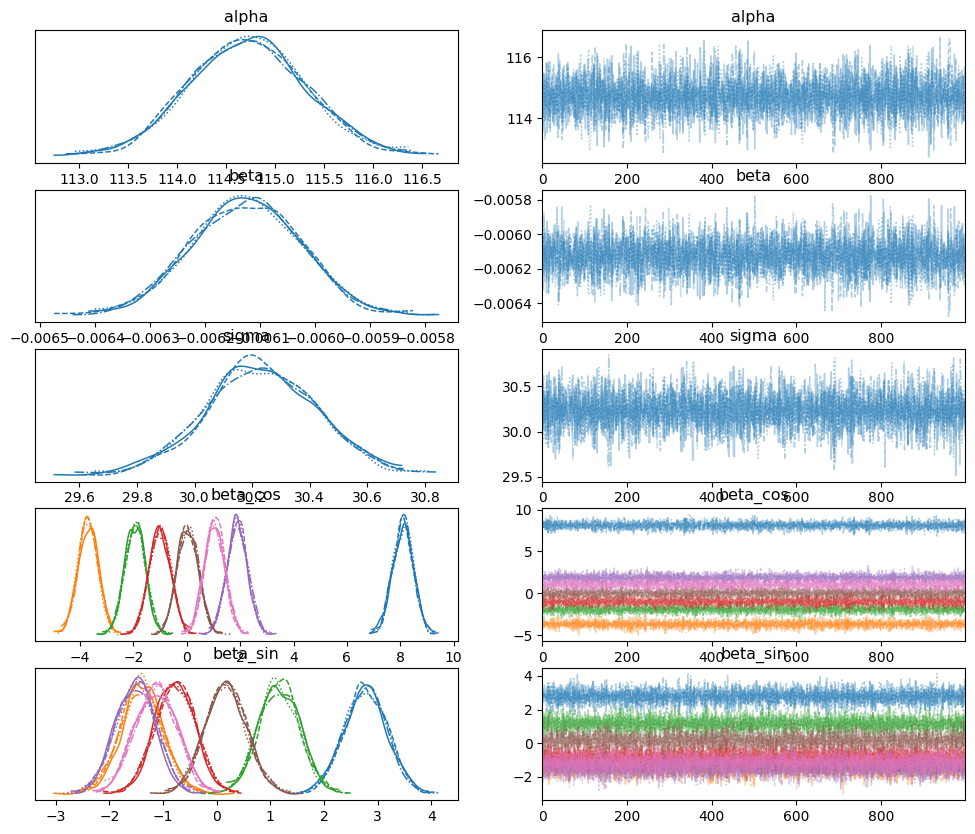

In [ ]:

# Convert fit to InferenceData
idata = az.from_cmdstanpy(fit)

# 1. Check Traceplots
# Look for "fuzzy caterpillars" - chains should overlap and not drift
az.plot_trace(idata)

# 2. Check Stats (R-hat and ESS)
summary = az.summary(idata)
print(summary)

In [ ]:
data_dict

{'n': 10373,
 't': array([    1,     2,     3, ..., 10371, 10372, 10373], shape=(10373,)),
 'y': array([77.47826087, 54.39130435, 56.17391304, ..., 29.00347826,
        31.0303125 , 27.3965625 ], shape=(10373,)),
 'num_seasonal': 2,
 'J': [2, 5],
 'periods': [7, 365.25]}

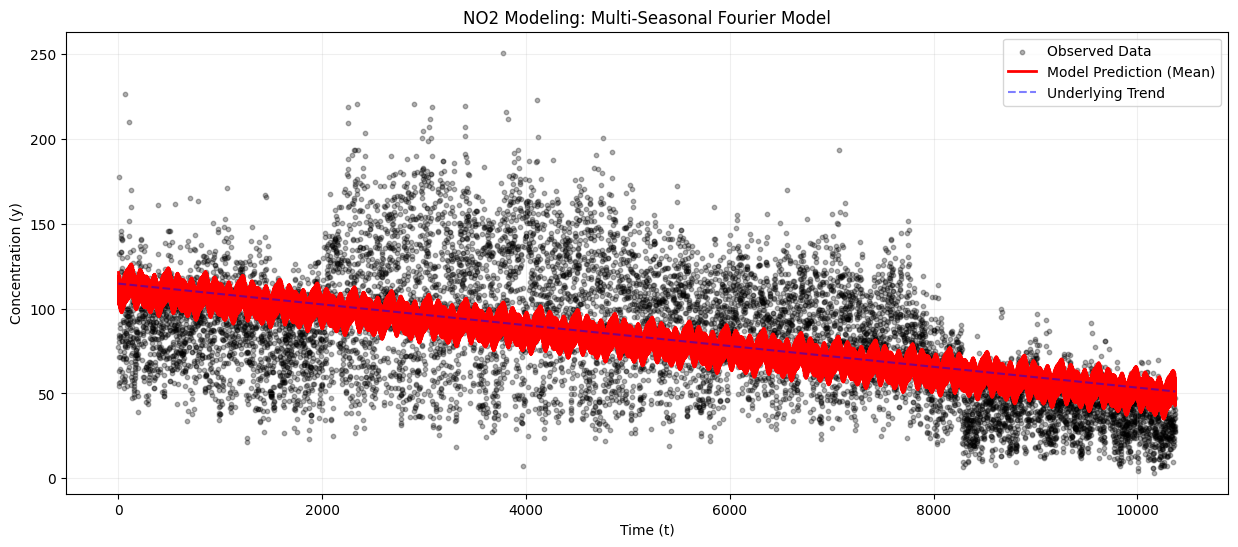

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract posterior means from the fit object
params = fit.stan_variables()
alpha_hat = params['alpha'].mean()
beta_hat = params['beta'].mean()
beta_cos_hat = params['beta_cos'].mean(axis=0)  # Shape (K,)
beta_sin_hat = params['beta_sin'].mean(axis=0)

# 2. Setup the time vector and frequencies (from your data dictionary)
# Make sure these match the data you fed into Stan
t_vals = df['day'].values
y_vals = df['no2'].values
num_seasonal = data_dict['num_seasonal']
J = data_dict['J']
periods = data_dict['periods']
omega = 2 * np.pi / np.array(periods)

# 3. Reconstruct the trend and seasonality
# Start with the linear trend
mu_pred = alpha_hat + beta_hat * t_vals

# Add the seasonal components using the same 'pos' logic as your Stan code
pos = 0
for s in range(num_seasonal):
    for j in range(1, J[s] + 1):
        mu_pred += (beta_cos_hat[pos] * np.cos(j * omega[s] * t_vals) +
                    beta_sin_hat[pos] * np.sin(j * omega[s] * t_vals))
        pos += 1


# 4. Plotting
plt.figure(figsize=(15, 6))
plt.scatter(t_vals, y_vals, color='black', s=10, alpha=0.3, label='Observed Data')
plt.plot(t_vals, mu_pred, color='red', linewidth=2, label='Model Prediction (Mean)')

# Optional: Plot the Trend line alone to see the drift
trend_only = alpha_hat + beta_hat * t_vals
plt.plot(t_vals, trend_only, color='blue', linestyle='--', alpha=0.5, label='Underlying Trend')
plt.title("NO2 Modeling: Multi-Seasonal Fourier Model")
plt.xlabel("Time (t)")
plt.ylabel("Concentration (y)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

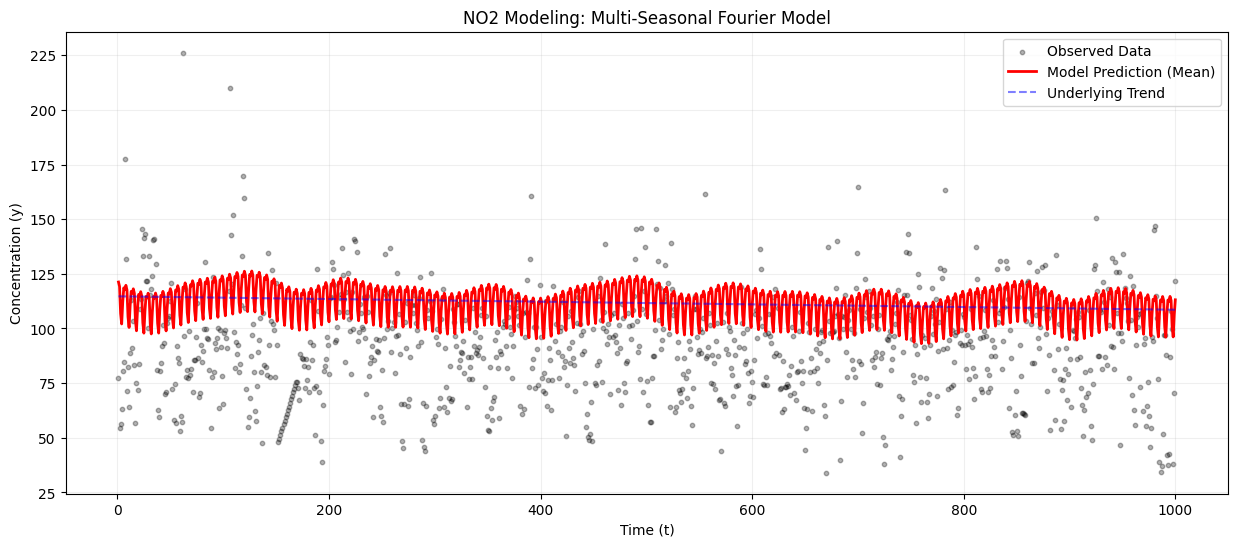

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract posterior means from the fit object
params = fit.stan_variables()
alpha_hat = params['alpha'].mean()
beta_hat = params['beta'].mean()
beta_cos_hat = params['beta_cos'].mean(axis=0)  # Shape (K,)
beta_sin_hat = params['beta_sin'].mean(axis=0)

# 2. Setup the time vector and frequencies (from your data dictionary)
# Make sure these match the data you fed into Stan
t_vals = df['day'].values
y_vals = df['no2'].values
num_seasonal = data_dict['num_seasonal']
J = data_dict['J']
periods = data_dict['periods']
omega = 2 * np.pi / np.array(periods)

# 3. Reconstruct the trend and seasonality
# Start with the linear trend
mu_pred = alpha_hat + beta_hat * t_vals

# Add the seasonal components using the same 'pos' logic as your Stan code
pos = 0
for s in range(num_seasonal):
    for j in range(1, J[s] + 1):
        mu_pred += (beta_cos_hat[pos] * np.cos(j * omega[s] * t_vals) +
                    beta_sin_hat[pos] * np.sin(j * omega[s] * t_vals))
        pos += 1
t_vals = t_vals[:1000]
y_vals = y_vals[:1000]
mu_pred = mu_pred[:1000]
# 4. Plotting
plt.figure(figsize=(15, 6))
plt.scatter(t_vals, y_vals, color='black', s=10, alpha=0.3, label='Observed Data')
plt.plot(t_vals, mu_pred, color='red', linewidth=2, label='Model Prediction (Mean)')

# Optional: Plot the Trend line alone to see the drift
trend_only = alpha_hat + beta_hat * t_vals
trend_only = trend_only[:1000]
plt.plot(t_vals, trend_only, color='blue', linestyle='--', alpha=0.5, label='Underlying Trend')

plt.title("NO2 Modeling: Multi-Seasonal Fourier Model")
plt.xlabel("Time (t)")
plt.ylabel("Concentration (y)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [1]:
import pickle 

with open("../no2_model_fit.pkl", "r") as f:
    fit = pickle.load(f)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 53: character maps to <undefined>

In [15]:
import arviz as az
idata = az.from_netcdf("../no2_results_mseason.nc")

In [16]:
idata

Inference data with groups:
	> posterior
	> sample_stats

In [10]:
stan_data = data_dict
data_dict

{'n': 10373,
 't': array([    1,     2,     3, ..., 10371, 10372, 10373], shape=(10373,)),
 'y': array([77.47826087, 54.39130435, 56.17391304, ..., 29.00347826,
        31.0303125 , 27.3965625 ], shape=(10373,)),
 'num_seasonal': 2,
 'J': [2, 5],
 'periods': [7, 365.25]}

In [12]:
import numpy as np
import pandas as pd

# Flatten posterior draws (chains × draws → n_draws)
def flatten(var):
    return var.values.reshape(-1, *var.shape[2:])

alpha = flatten(idata.posterior["alpha"])  # shape (n_draws,)
beta = flatten(idata.posterior["beta"])
sigma = flatten(idata.posterior["sigma"])
beta_cos = flatten(idata.posterior["beta_cos"])  # shape (n_draws, S)
beta_sin = flatten(idata.posterior["beta_sin"])

# Observed data
t_vals = np.array(stan_data["t"])
y_vals = np.array(stan_data["y"])
S = stan_data["num_seasonal"]
periods = np.array(stan_data["periods"])
omega = 2 * np.pi / periods

n_draws = alpha.shape[0]
n_obs = len(y_vals)

# Compute mu
mu = np.zeros((n_draws, n_obs))
for s in range(S):
    mu += beta_cos[:, s][:, None] * np.cos(omega[s] * t_vals)[None, :]
    mu += beta_sin[:, s][:, None] * np.sin(omega[s] * t_vals)[None, :]

# Add linear trend
mu += alpha[:, None] + beta[:, None] * t_vals

# Compute log-likelihood
log_lik = -0.5 * np.log(2 * np.pi * sigma[:, None]**2) - 0.5 * ((y_vals - mu) / sigma[:, None])**2

# Export to CSV
df_loglik = pd.DataFrame(log_lik)
df_loglik.to_csv("log_lik_longseason.csv", index=False)

print("Log-likelihoods exported to log_lik_longseason.csv")


Log-likelihoods exported to log_lik_longseason.csv


In [10]:
# Flatten chains and draws into a single dimension (e.g., 4 chains x 1000 draws = 4000 samples)
posterior = idata.posterior.stack(sample=("chain", "draw"))

# Access individual parameters
alphas = posterior["alpha"].values      # Shape: (samples,)
betas = posterior["beta"].values        # Shape: (samples,)
sigmas = posterior["sigma"].values      # Shape: (samples,)

# For vectors like Fourier coefficients
beta_cos = posterior["beta_cos"].values # Shape: (K, samples)
beta_sin = posterior["beta_sin"].values # Shape: (K, samples)

# Note: Vectors in ArviZ often have the dimension as the first axis.
# To match the previous logic, we transpose them:
beta_cos = beta_cos.T  # Now (samples, K)
beta_sin = beta_sin.T  # Now (samples, K)

In [12]:
df = pd.read_csv("../no2.csv")

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract ALL draws (not just means)
t_vals = df['day'].values#[:1000]
y_vals = df['no2'].values#[:1000]
num_draws = alphas.shape[0]

# 2. Reconstruct mu for EVERY draw (Vectorized over draws)
# This creates a matrix of shape (num_draws, 1000)
mu_draws = alphas[:, np.newaxis] + betas[:, np.newaxis] * t_vals

pos = 0
for s in range(data_dict['num_seasonal']):
    for j in range(1, data_dict['J'][s] + 1):
        omega_sj = j * (2 * np.pi / data_dict['periods'][s])
        mu_draws += (beta_cos[:, pos][:, np.newaxis] * np.cos(omega_sj * t_vals) + (beta_cos[:, pos][:, np.newaxis] * np.cos(omega_sj * t_vals) +
                     beta_sin[:, pos][:, np.newaxis] * np.sin(omega_sj * t_vals))
        pos += 1

# 3. Add noise (sigma) to get the actual "Predictive" distribution
# This represents where NEW data points would likely fall
y_pred_draws = mu_draws + np.random.normal(0, sigmas[:, np.newaxis], size=mu_draws.shape)

# 4. Calculate intervals
mu_mean = np.mean(mu_draws, axis=0)
mu_hdi_low = np.percentile(mu_draws, 2.5, axis=0)
mu_hdi_high = np.percentile(mu_draws, 97.5, axis=0)

y_pred_low = np.percentile(y_pred_draws, 2.5, axis=0)
y_pred_high = np.percentile(y_pred_draws, 97.5, axis=0)

# 5. Plotting
plt.figure(figsize=(15, 7))

# Shaded area for the "Predictive Interval" (Uncertainty + Noise)
plt.fill_between(t_vals, y_pred_low, y_pred_high, color='gray', alpha=0.2, label='95% Predictive Interval')

# Shaded area for the "Mean Uncertainty" (Just the fit uncertainty)
plt.fill_between(t_vals, mu_hdi_low, mu_hdi_high, color='red', alpha=0.4, label='95% Mu Credible Interval')

plt.plot(t_vals, y_vals, color='black', alpha=0.4, label='Actual Observations')
plt.plot(t_vals, mu_mean, color='red', lw=1.5, label='Posterior Mean')

plt.title("NO2 Posterior Predictive: Uncertainty and Noise")
plt.xlabel("Day")
plt.ylabel("NO2")
plt.legend(loc='upper right')
plt.show()

SyntaxError: '(' was never closed (3397381590.py, line 17)

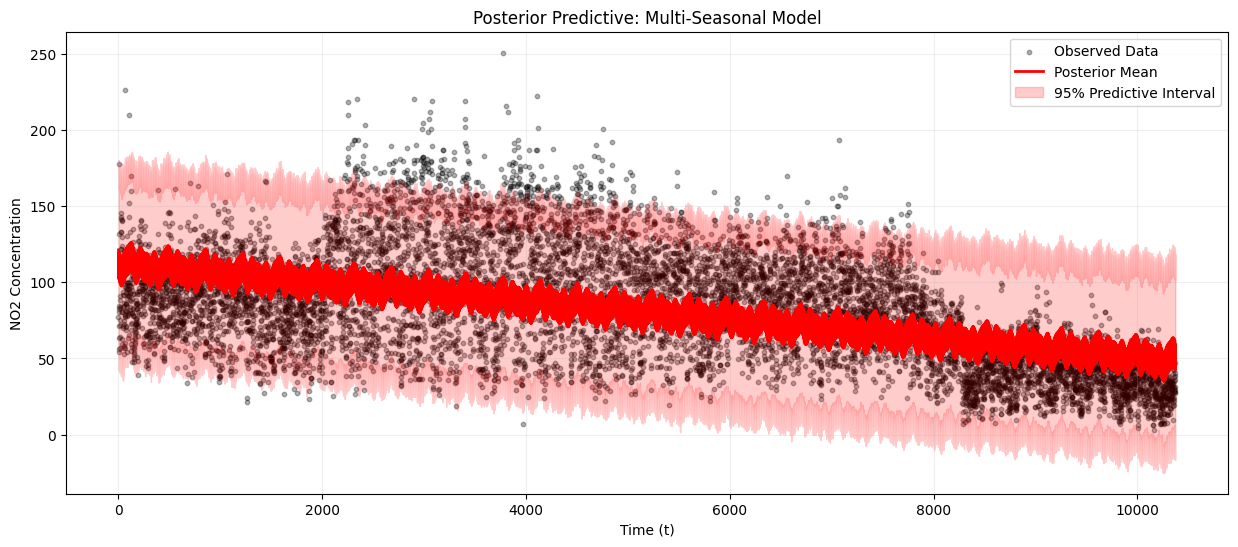

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract posterior draws (not just means)
alpha = idata.posterior['alpha'].values.reshape(-1)        # (num_draws,)
beta = idata.posterior['beta'].values.reshape(-1)
beta_cos = idata.posterior['beta_cos'].values.reshape(-1, idata.posterior['beta_cos'].shape[-1])
beta_sin = idata.posterior['beta_sin'].values.reshape(-1, idata.posterior['beta_sin'].shape[-1])
sigma = idata.posterior['sigma'].values.reshape(-1)
# 2. Time vector and seasonal frequencies
t_vals = df['day'].values
y_vals = df['no2'].values
num_draws = alpha.shape[0]

num_seasonal = data_dict['num_seasonal']
J = data_dict['J']
periods = data_dict['periods']
omega = 2 * np.pi / np.array(periods)

# 3. Compute mu for all posterior draws
mu_draws = np.zeros((num_draws, len(t_vals)))

pos = 0
for s in range(num_seasonal):
    for j in range(1, J[s]+1):
        mu_draws += (beta_cos[:, pos][:, None] * np.cos(j * omega[s] * t_vals) +
                     beta_sin[:, pos][:, None] * np.sin(j * omega[s] * t_vals))
        pos += 1

mu_draws += alpha[:, None] + beta[:, None] * t_vals

# 4. Posterior predictive draws: add observation noise
y_pred_draws = mu_draws + np.random.normal(0, sigma[:, None], size=mu_draws.shape)

# 5. Save posterior predictive draws
np.save("posterior_pred_multi.npy", y_pred_draws)

# 6. Optional: Plot posterior mean and 95% PI
mu_mean = mu_draws.mean(axis=0)
y_low = np.percentile(y_pred_draws, 2.5, axis=0)
y_high = np.percentile(y_pred_draws, 97.5, axis=0)

plt.figure(figsize=(15,6))
plt.scatter(t_vals, y_vals, color='black', s=10, alpha=0.3, label='Observed Data')
plt.plot(t_vals, mu_mean, color='red', linewidth=2, label='Posterior Mean')
plt.fill_between(t_vals, y_low, y_high, color='red', alpha=0.2, label='95% Predictive Interval')
plt.xlabel("Time (t)")
plt.ylabel("NO2 Concentration")
plt.title("Posterior Predictive: Multi-Seasonal Model")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
